# Library

In [173]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np
import sympy as sp
import random
import time
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

### Init

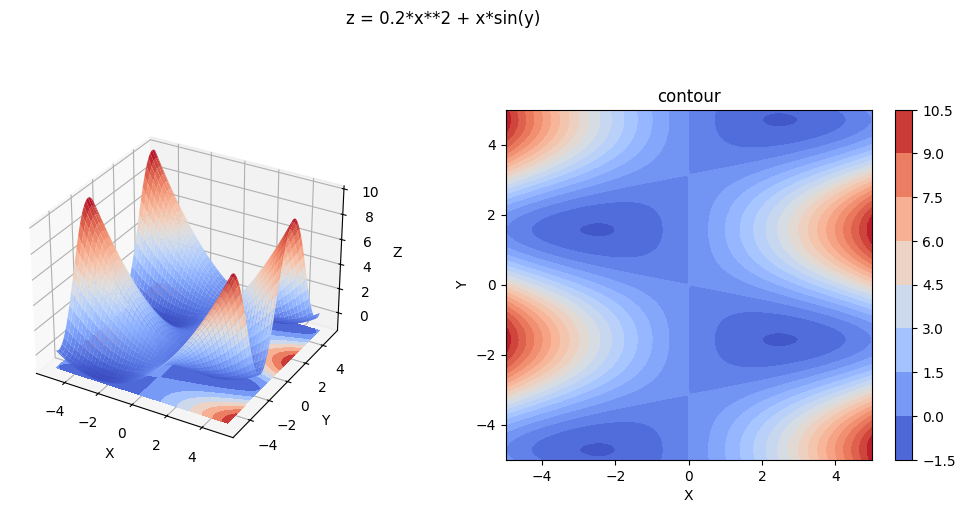

In [174]:
# tạo dữ liệu
start = -5
end = 5
X = np.linspace(start, end, 100)
Y = np.linspace(start, end, 100)
X, Y = np.meshgrid(X, Y)

x, y = sp.symbols('x y')
# hàm mất mát
f_expr = x*sp.sin(y) + 0.2*x**2
f = sp.lambdify((x, y), f_expr, 'numpy')

# đạo hàm riêng
df_x = sp.lambdify((x, y), sp.diff(f_expr, x), 'numpy')
df_y = sp.lambdify((x, y), sp.diff(f_expr, y), 'numpy')

# vẽ đồ thị hàm mất mát
Z = f(X, Y)
fig = plt.figure(figsize=(13, 10))
ax = fig.add_subplot(221, projection='3d')
ax.plot_surface(X, Y, Z, cmap=cm.coolwarm)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

cset = ax.contourf(X, Y, Z,
                   zdir ='z',
                   offset = np.min(Z),
                   cmap = 'coolwarm')

ax2 = fig.add_subplot(222)
ax2.contourf(X, Y, Z, cmap='coolwarm', levels=20)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.colorbar = plt.colorbar(cset, ax=ax2, orientation='vertical')
ax2.set_title("contour")

fig.suptitle("z = " + str(f_expr))
plt.show()

In [175]:
# vẽ đồ thị hàm mất mát và theta tại các bước của thuật toán
def my3DPlot(model):
    Z = f(X, Y)

    fig = plt.figure(figsize=(13, 10))
    ax = fig.add_subplot(221, projection='3d')
    ax.plot_surface(X, Y, Z, cmap=cm.coolwarm)

    ax2 = fig.add_subplot(222)
    ax2.contourf(X, Y, Z, cmap='coolwarm', levels=20)
    
    thetas = np.array(model.thetas)
    # vẽ điểm và đường đi của thuật toán trên đồ thị 3D
    for i in range(len(thetas)):
        ax.scatter(thetas[i][0], thetas[i][1], f(thetas[i][0], thetas[i][1]), c='purple', marker='o', s=10)
        ax2.scatter(thetas[i][0], thetas[i][1], c='purple', marker='o', s=10)
    
    # vẽ đường đi của thuật toán trên mặt contour Z của hàm mất mát
    for i in range(len(thetas)-1):
        ax.plot([thetas[i][0], thetas[i+1][0]], [thetas[i][1], thetas[i+1][1]], 
                [f(thetas[i][0], thetas[i][1]), f(thetas[i+1][0], thetas[i+1][1])], 
                c='purple')
        ax2.plot([thetas[i][0], thetas[i+1][0]], [thetas[i][1], thetas[i+1][1]], c='purple')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.colorbar = plt.colorbar(cset, ax=ax2, orientation='vertical')
    ax2.set_title("contour")

    fig.suptitle(model.name + "\ntheta0 = " + str(model.theta0) + "\nminimum = " + str(model.minimum))
    plt.show()

### Gradient Descent

Khởi tạo theta0: [-4.744135315318966, -3.225767783648801]
Số vòng lặp: 528
Thời gian chạy: 0.0 giây
Giá trị hàm tối ưu: -1.2499999995084825 tại điểm: (-2.5000495740624635, -4.712388980384687)


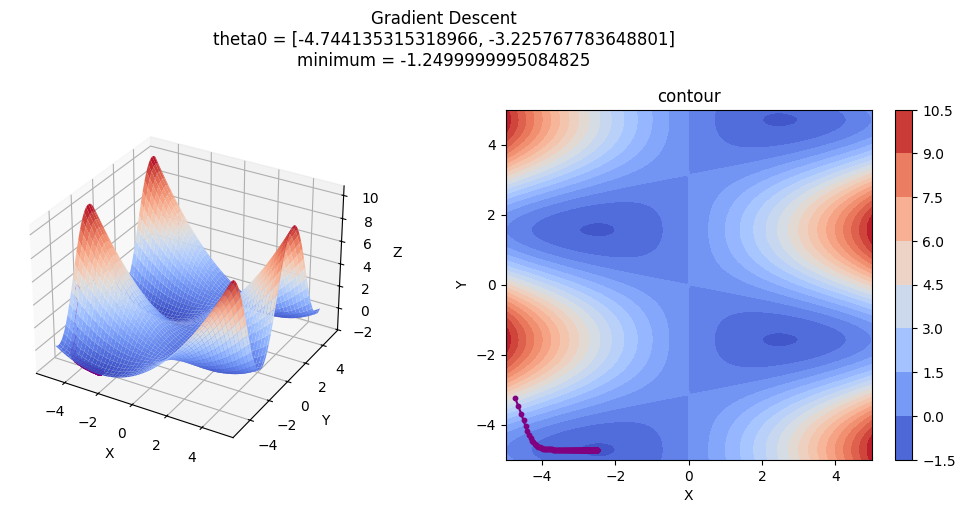

In [176]:

class GD:
    def __init__(self, learning_rate=0.05, max_iter=1000, tol=1e-6):
        self.name = "Gradient Descent"  # Thêm thuộc tính name
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.thetas = []

    def update(self, theta0=None):
        # Nếu không cung cấp giá trị khởi tạo, chọn ngẫu nhiên trong khoảng [start, end]
        if theta0 is None:
            theta0 = [random.uniform(start, end), random.uniform(start, end)]
        self.theta0 = theta0
        self.thetas.append(theta0)

        start_time = time.time()
        for i in range(self.max_iter):
            current = self.thetas[-1]
            # Tính gradient tại điểm hiện tại
            grad = np.array([df_x(current[0], current[1]), df_y(current[0], current[1])])
            # Cập nhật theo công thức gradient descent
            step = -self.learning_rate * grad
            if np.linalg.norm(step) < self.tol:
                break
            new_theta = [current[0] + step[0], current[1] + step[1]]
            self.thetas.append(new_theta)
        self.training_time = time.time() - start_time
        
        # Gán giá trị tối ưu cho thuộc tính minimum
        self.minimum = f(self.thetas[-1][0], self.thetas[-1][1])
        
        print("Khởi tạo theta0:", self.theta0)
        print("Số vòng lặp:", len(self.thetas))
        print("Thời gian chạy:", self.training_time, "giây")
        print("Giá trị hàm tối ưu:", self.minimum, "tại điểm:", tuple(self.thetas[-1]))
        return self.thetas

gd = GD()
gd.update()
my3DPlot(gd)

### Batch Gradient Descent

theta0 [2.1778780408125424, 2.3177872699907978]
minimum value =  -1.2499999995093036  at (2.499950467368044, 4.712388980384687) after 522 iterations in 0.0 seconds


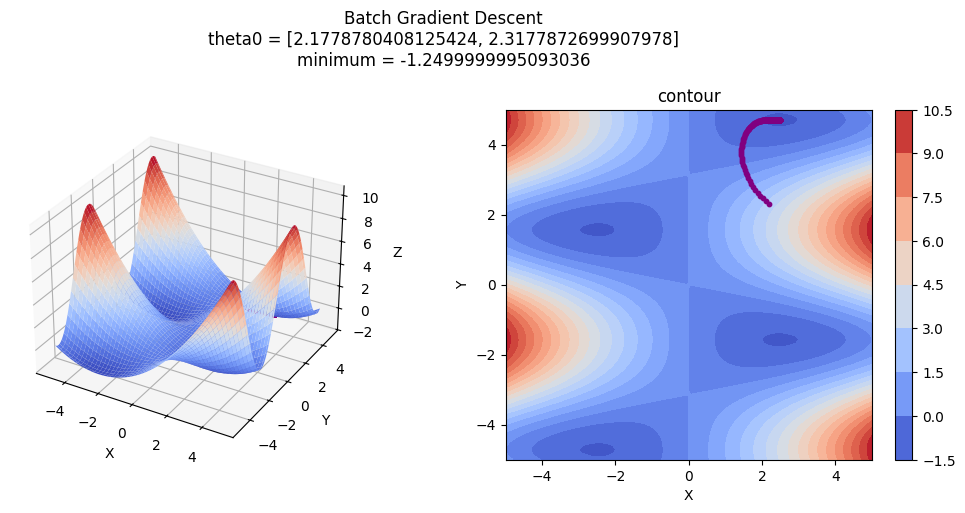

In [177]:
class BGD:
    def __init__(self, learning_rate=0.05, max_iter=1000, tol=1e-6):
        self.name = "Batch Gradient Descent"
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol

    def update(self, theta0=[random.uniform(start, end), random.uniform(start, end)]):
        self.theta0 = theta0
        self.thetas = [self.theta0]

        start_time = time.time()

        for _ in range(self.max_iter):
            gradient = np.array([df_x(self.thetas[-1][0], self.thetas[-1][1]), df_y(self.thetas[-1][0], self.thetas[-1][1])])
            diff = -self.learning_rate * gradient

            # dừng nếu cập nhật quá nhỏ
            distance = np.sqrt(np.sum(diff**2))
            if distance < self.tol:
                break
            
            self.thetas.append([self.thetas[-1][i] + diff[i] for i in range(len(diff))])

        self.training_time = time.time() - start_time

        print("theta0", self.theta0)
        self.minimum = f(self.thetas[-1][0], self.thetas[-1][1])
        print("minimum value = ", self.minimum, " at", tuple(self.thetas[-1]), 
              "after", len(self.thetas), "iterations in", self.training_time, "seconds")


bgd = BGD()
bgd.update()
my3DPlot(bgd)

### Stochastic Gradient Descent

start index [3.996107757563191, -2.683416993573451]
minimum value =  -0.9832796456474098  at (3.6492686260644467, -1.608231131734502) after 7 iterations in 0.0 seconds


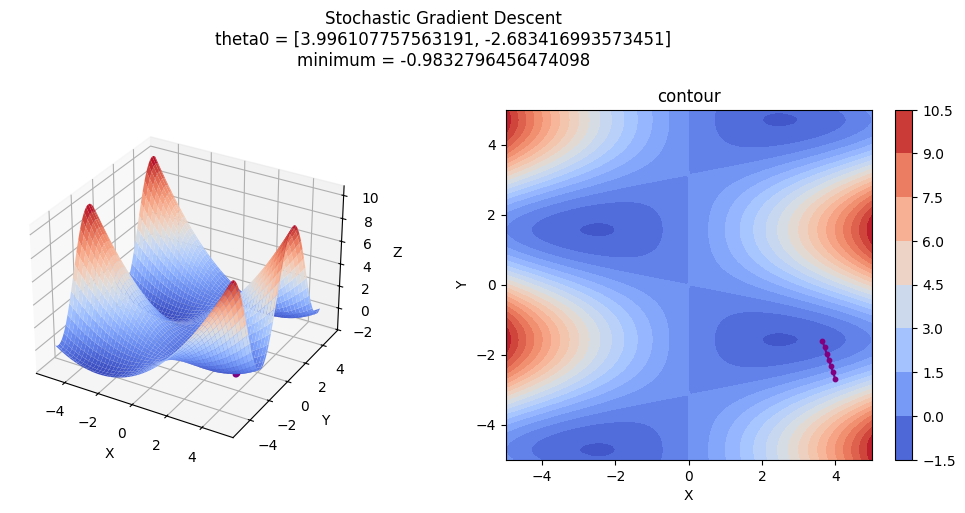

In [178]:
class SGD:
    def __init__(self, learning_rate=0.05, max_iter=1000, tol=1e-6):
        self.name = "Stochastic Gradient Descent"
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
    
    def update(self, theta0=[random.uniform(start, end), random.uniform(start, end)]):
        self.theta0 = theta0
        self.thetas = [theta0]

        start_time = time.time()

        for _ in range(self.max_iter):
            gradient = np.array([df_x(self.thetas[0][0], self.thetas[0][1]), df_y(self.thetas[0][0], self.thetas[0][1])])
            diff = -self.learning_rate * gradient

            # dừng nếu cập nhật quá nhỏ
            distance = np.sqrt(np.sum(diff**2))
            if distance < self.tol:
                break
            
            new_theta = [self.thetas[-1][i] + diff[i] for i in range(len(diff))]

            # kiểm tra giá trị theta có nằm trong khoảng cho phép hay không
            if new_theta[0] < start or new_theta[0] > end or new_theta[1] < start or new_theta[1] > end:
                continue
            
            # đảm bảo giá trị hàm mất mát giảm
            if f(new_theta[0], new_theta[1]) > f(self.thetas[-1][0], self.thetas[-1][1]):
                break

            self.thetas.append(new_theta)

        self.training_time = time.time() - start_time

        print("start index", self.thetas[0])
        self.minimum = f(self.thetas[-1][0], self.thetas[-1][1])
        print("minimum value = ", self.minimum, " at", 
              tuple(self.thetas[-1]), "after", len(self.thetas), "iterations in", self.training_time, "seconds")

sgd = SGD()
sgd.update()
my3DPlot(sgd)

### Mini-Batch Gradient Descent

start index [-3.1345262804938425, 2.4118475100549546]
minimum value =  -1.2499999995008257  at (-2.5000499586933347, 1.5707963267948974) after 463 iterations in 0.0064220428466796875 seconds


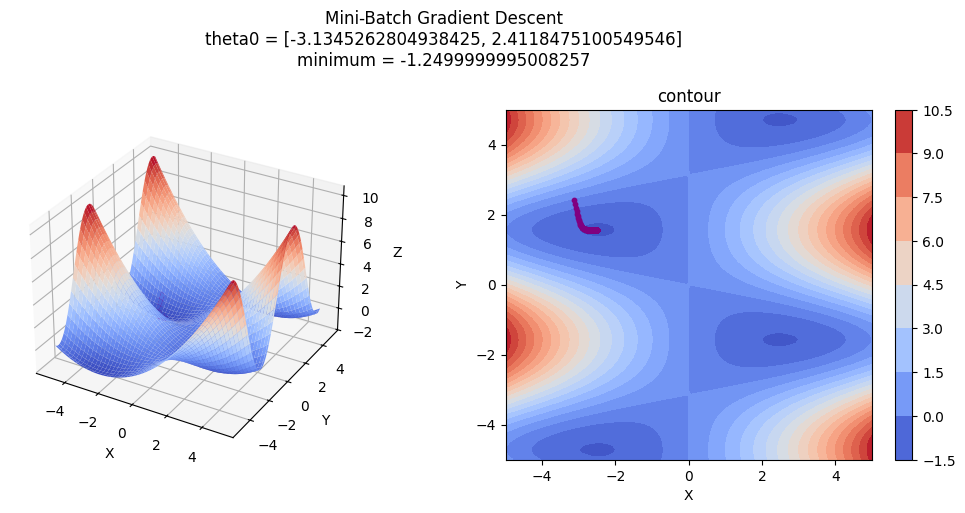

In [179]:
class MiniBGD:
    def __init__(self, learning_rate=0.05, max_iter=1000, tol=1e-6):
        self.name = "Mini-Batch Gradient Descent"
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        
    def update(self, theta0=[random.uniform(start, end), random.uniform(start, end)], size=10):
        self.theta0 = theta0
        self.thetas = [self.theta0]

        start_time = time.time()

        for _ in range(self.max_iter):
            gradient = np.array([df_x(self.thetas[-1][0], self.thetas[-1][1]), df_y(self.thetas[-1][0], self.thetas[-1][1])])
            diff = -self.learning_rate * gradient

            # dừng nếu cập nhật quá nhỏ
            distance = np.sqrt(np.sum(diff**2))
            if distance < self.tol:
                break
            
            new_theta = [self.thetas[-1][i] + diff[i] for i in range(len(diff))]

            # kiểm tra giá trị theta có nằm trong khoảng cho phép hay không
            if new_theta[0] < start or new_theta[0] > end or new_theta[1] < start or new_theta[1] > end:
                continue

            self.thetas.append(new_theta)

        self.training_time = time.time() - start_time
        
        print("start index", self.thetas[0])
        self.minimum = f(self.thetas[-1][0], self.thetas[-1][1])
        print("minimum value = ", self.minimum, " at", 
              tuple(self.thetas[-1]), "after", len(self.thetas), "iterations in", self.training_time, "seconds")

minibgd = MiniBGD()
minibgd.update()
my3DPlot(minibgd)

## Momentum

start index [-4.582199926758409, 1.89390841218915]
minimum value =  -1.2499999996862612  at (-2.4999643775156333, 1.5708032519578152) after 208 iterations in 0.0 seconds


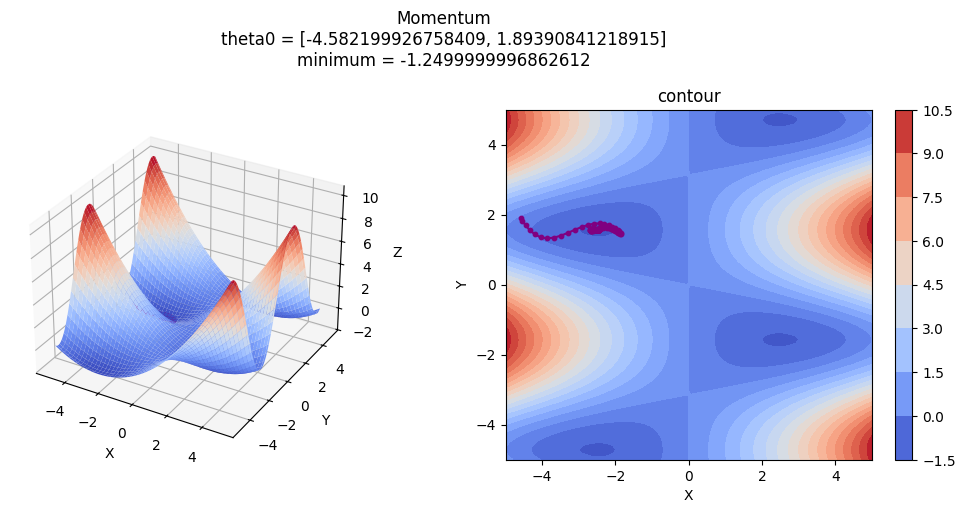

In [180]:
class Momentum:
    def __init__(self, learning_rate=0.05, max_iter=1000, beta=0.9, tol=1e-6):
        self.name = "Momentum"
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.beta = beta
        self.tol = tol
        self.v = 0
    
    def update(self, theta0=[random.uniform(start, end), random.uniform(start, end)]):
        self.theta0 = theta0
        self.thetas = [self.theta0]

        start_time = time.time()
        
        for _ in range(self.max_iter):
            self.v = self.v * self.beta - self.learning_rate * np.array([df_x(self.thetas[-1][0], self.thetas[-1][1]), 
                                                                         df_y(self.thetas[-1][0], self.thetas[-1][1])])

            # dừng nếu cập nhật quá nhỏ
            distance = np.sqrt(np.sum(self.v**2))
            if distance < self.tol:
                break

            new_theta = [self.thetas[-1][i] + self.v[i] for i in range(len(self.v))]

            # kiểm tra giá trị theta có nằm trong khoảng cho phép không
            if new_theta[0] < start or new_theta[0] > end or new_theta[1] < start or new_theta[1] > end:
                continue
            
            self.thetas.append(new_theta)

        self.training_time = time.time() - start_time

        print("start index", self.thetas[0])
        self.minimum = f(self.thetas[-1][0], self.thetas[-1][1])
        print("minimum value = ", self.minimum, " at", 
              tuple(self.thetas[-1]), "after", len(self.thetas), "iterations in", self.training_time, "seconds")

momentum = Momentum()
momentum.update()
my3DPlot(momentum)


## RMSProp

start index [-4.783837874380492, -2.252653864417611]
minimum value =  -1.2499999999998457  at (-2.500000877838324, -4.71238898038469) after 100 iterations in 0.002008676528930664 seconds


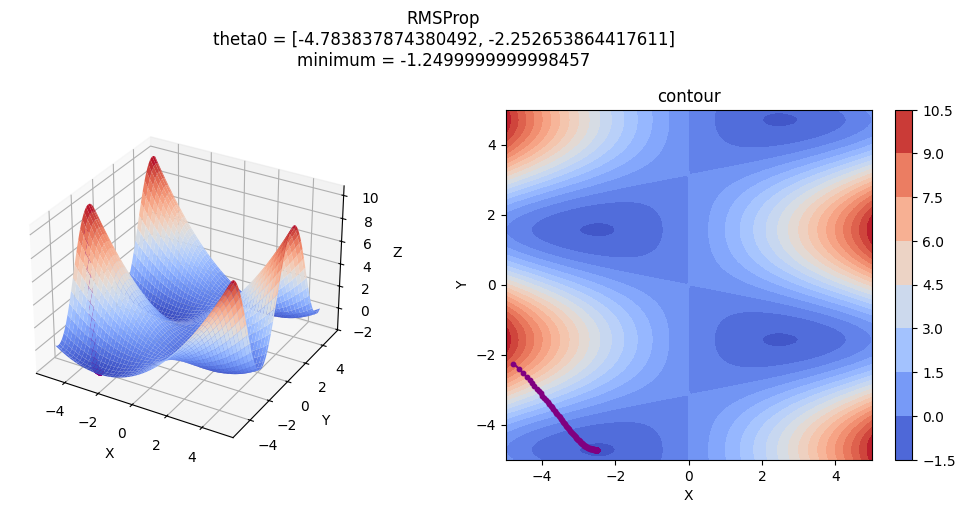

In [181]:
class RMSProp:
    def __init__(self, learning_rate=0.05, max_iter=1000, beta=0.9, tol=1e-6):
        self.name = "RMSProp"
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.beta = beta
        self.tol = tol
        self.epsilon = 1e-8
        self.E = 0

    def update(self, theta0=[random.uniform(start, end), random.uniform(start, end)]):
        self.theta0 = theta0
        self.thetas = [self.theta0]

        start_time = time.time()
        
        for _ in range(self.max_iter):
            gradient = np.array([df_x(self.thetas[-1][0], self.thetas[-1][1]), df_y(self.thetas[-1][0], self.thetas[-1][1])])
            self.E = self.beta * self.E + (1 - self.beta) * gradient**2
            diff = -self.learning_rate * gradient / np.sqrt(self.E + self.epsilon)

            # dừng nếu cập nhật quá nhỏ
            distance = np.sqrt(np.sum(diff**2))
            if distance < self.tol:
                break

            new_theta = [self.thetas[-1][i] + diff[i] for i in range(len(diff))]

            # kiểm tra giá trị theta có nằm trong khoảng cho phép không
            if new_theta[0] < start or new_theta[0] > end or new_theta[1] < start or new_theta[1] > end:
                continue
            
            self.thetas.append(new_theta)

        self.training_time = time.time() - start_time

        print("start index", self.thetas[0])
        self.minimum = f(self.thetas[-1][0], self.thetas[-1][1])
        print("minimum value = ", self.minimum, " at", 
              tuple(self.thetas[-1]), "after", len(self.thetas), "iterations in", self.training_time, "seconds")

rmsprop = RMSProp()
rmsprop.update()
my3DPlot(rmsprop)

## Adam

start index [1.3734239839786913, -0.1936313010032329]
minimum value =  -1.2499999998982072  at (2.500018737207444, -1.5707913007838141) after 232 iterations in 0.015787839889526367 seconds


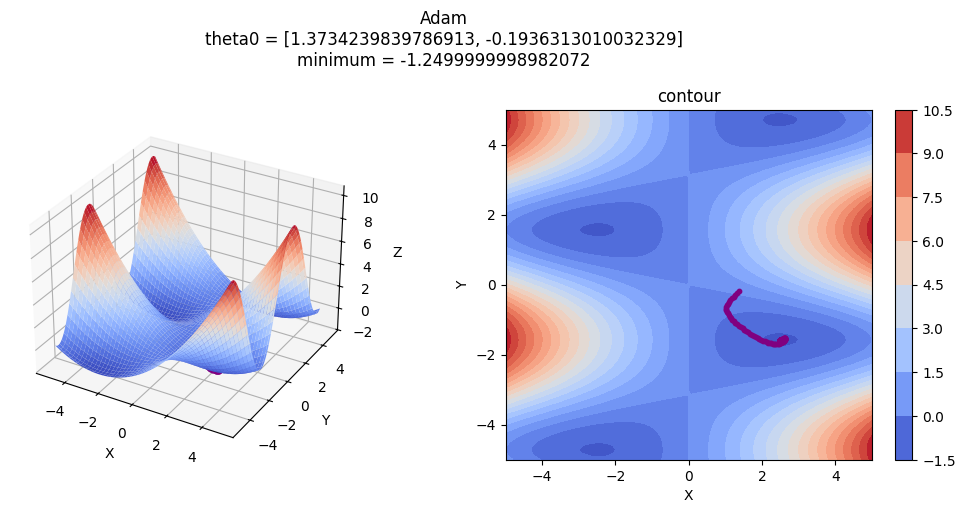

In [182]:
class Adam:
    def __init__(self, learning_rate=0.05, max_iter=1000, beta1=0.9, beta2=0.999, tol=1e-6):
        self.name = "Adam"
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.beta1 = beta1
        self.beta2 = beta2
        self.tol = tol
        self.epsilon = 1e-8
        self.m = 0
        self.v = 0
        self.t = 0

    def update(self, theta0=[random.uniform(start, end), random.uniform(start, end)]):
        self.theta0 = theta0
        self.thetas = [self.theta0]

        start_time = time.time()
        
        for _ in range(self.max_iter):
            self.t += 1
            gradient = np.array([df_x(self.thetas[-1][0], self.thetas[-1][1]), df_y(self.thetas[-1][0], self.thetas[-1][1])])
            self.m = self.beta1 * self.m + (1 - self.beta1) * gradient
            self.v = self.beta2 * self.v + (1 - self.beta2) * gradient**2
            m_hat = self.m / (1 - self.beta1**self.t)
            v_hat = self.v / (1 - self.beta2**self.t)
            diff = -self.learning_rate * m_hat / (np.sqrt(v_hat) + self.epsilon)

            # dừng nếu cập nhật quá nhỏ
            distance = np.sqrt(np.sum(diff**2))
            if distance < self.tol:
                break

            new_theta = [self.thetas[-1][i] + diff[i] for i in range(len(diff))]

            # kiểm tra giá trị theta có nằm trong khoảng cho phép không
            if new_theta[0] < start or new_theta[0] > end or new_theta[1] < start or new_theta[1] > end:
                continue
            
            self.thetas.append(new_theta)

        self.training_time = time.time() - start_time

        print("start index", self.thetas[0])
        self.minimum = f(self.thetas[-1][0], self.thetas[-1][1])
        print("minimum value = ", self.minimum, " at", 
              tuple(self.thetas[-1]), "after", len(self.thetas), "iterations in", self.training_time, "seconds")

adam = Adam()
adam.update()
my3DPlot(adam)

# House Pricing

### Models

In [183]:
class BatchGD_HousePrice:
    def __init__(self, learning_rate=0.01, max_iter=1000, tol=1e-6):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.name = "Batch Gradient Descent for House Price Prediction"
    
    def fit(self, X, y):
        """
        X: ma trận đặc trưng, đã có thêm cột bias (1) nếu cần.
        y: vector giá nhà (mảng numpy dạng (n_samples, ) hoặc (n_samples,1))
        """
        n_samples, n_features = X.shape
        # Khởi tạo vector trọng số theta với giá trị 0
        self.theta = np.zeros(n_features)
        self.thetas = [self.theta.copy()]  # lưu lại lịch sử theta
        self.losses = []  # lưu lại lịch sử loss
        
        start_time = time.time()
        
        for i in range(self.max_iter):
            predictions = X.dot(self.theta)
            error = predictions - y.flatten()
            loss = np.mean(error ** 2)
            self.losses.append(loss)
            
            # Tính gradient của MSE
            gradient = (2 / n_samples) * X.T.dot(error)
            diff = -self.learning_rate * gradient
            
            # Cập nhật theta
            self.theta += diff
            self.thetas.append(self.theta.copy())
            
            # Dừng nếu sự thay đổi của theta quá nhỏ
            if np.linalg.norm(diff) < self.tol:
                print(f"Dừng sau {i+1} iterations với diff = {np.linalg.norm(diff):.6f}")
                break
        
        self.training_time = time.time() - start_time
        self.minimum = self.losses[-1]
        print("Kết quả huấn luyện:")
        print("Thời gian huấn luyện:", self.training_time, "giây")
        print("Loss cuối cùng:", self.minimum)
    
    def predict(self, X):
        return X.dot(self.theta)

In [184]:
class StochasticGD_HousePrice:
    def __init__(self, learning_rate=0.01, max_iter=1000, tol=1e-6):
        self.learning_rate = learning_rate
        self.max_iter = max_iter      # số epoch
        self.tol = tol
        self.name = "Stochastic Gradient Descent for House Price Prediction"
        
    def fit(self, X, y):
        """
        Huấn luyện mô hình sử dụng Stochastic GD.
        X: ma trận đặc trưng, đã có cột bias (shape: [n_samples, n_features])
        y: vector mục tiêu (shape: [n_samples] hoặc [n_samples, 1])
        """
        n_samples, n_features = X.shape
        self.theta = np.zeros(n_features)   # khởi tạo theta
        self.thetas = [self.theta.copy()]
        self.losses = []
        start_time = time.time()
        
        for epoch in range(self.max_iter):
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            for i in indices:
                xi = X[i:i+1]  # giữ nguyên định dạng ma trận (1, n_features)
                yi = y[i]
                prediction = xi.dot(self.theta)
                error = prediction - yi
                # Gradient cho một mẫu
                gradient = 2 * xi.T.dot(error)
                diff = -self.learning_rate * gradient.flatten()
                self.theta += diff
                self.thetas.append(self.theta.copy())
            # Tính loss trên toàn bộ tập huấn luyện sau mỗi epoch
            full_pred = X.dot(self.theta)
            loss = np.mean((full_pred - y.flatten()) ** 2)
            self.losses.append(loss)
            if np.linalg.norm(diff) < self.tol:
                print(f"Dừng sau {epoch+1} epochs với diff = {np.linalg.norm(diff):.6f}")
                break
        
        self.training_time = time.time() - start_time
        self.minimum = self.losses[-1]
        print(f"Training completed in {self.training_time:.4f} seconds, final loss = {self.minimum:.6f}")
        
    def predict(self, X):
        return X.dot(self.theta)

In [185]:
class MiniBatchGD_HousePrice:
    def __init__(self, learning_rate=0.01, max_iter=1000, batch_size=32, tol=1e-6):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.batch_size = batch_size
        self.tol = tol
        self.name = "Mini-Batch Gradient Descent for House Price Prediction"
    
    def fit(self, X, y):
        """
        Huấn luyện mô hình bằng mini-batch gradient descent.
        
        Parameters:
        - X: ma trận đặc trưng với cột bias (shape: [n_samples, n_features])
        - y: vector giá trị mục tiêu (shape: [n_samples] hoặc [n_samples, 1])
        """
        n_samples, n_features = X.shape
        self.theta = np.zeros(n_features)  # khởi tạo trọng số
        self.thetas = [self.theta.copy()]   # lưu lại lịch sử theta
        self.losses = []                    # lưu lại lịch sử loss
        
        start_time = time.time()
        
        for epoch in range(self.max_iter):
            # Xáo trộn dữ liệu mỗi epoch
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            
            for start in range(0, n_samples, self.batch_size):
                end = start + self.batch_size
                batch_idx = indices[start:end]
                X_batch = X[batch_idx]
                y_batch = y[batch_idx]
                
                # Dự đoán và tính error của mini-batch
                predictions = X_batch.dot(self.theta)
                error = predictions - y_batch.flatten()
                
                # Tính gradient của MSE cho mini-batch
                gradient = (2 / X_batch.shape[0]) * X_batch.T.dot(error)
                diff = -self.learning_rate * gradient
                
                # Cập nhật theta
                self.theta += diff
            
            # Sau mỗi epoch, tính loss trên toàn bộ tập dữ liệu huấn luyện
            predictions_epoch = X.dot(self.theta)
            error_epoch = predictions_epoch - y.flatten()
            loss = np.mean(error_epoch**2)
            self.losses.append(loss)
            self.thetas.append(self.theta.copy())
            
            # Nếu sự thay đổi sau một epoch quá nhỏ, dừng huấn luyện
            if np.linalg.norm(diff) < self.tol:
                print(f"Dừng sau {epoch+1} epochs với diff = {np.linalg.norm(diff):.6f}")
                break
        
        self.training_time = time.time() - start_time
        self.minimum = self.losses[-1]
        print("Kết quả huấn luyện:")
        print("Thời gian huấn luyện:", self.training_time, "giây")
        print("Loss cuối cùng:", self.minimum)
    
    def predict(self, X):
        return X.dot(self.theta)


In [186]:
class MomentumGD_HousePrice:
    def __init__(self, learning_rate=0.01, max_iter=1000, tol=1e-6, beta=0.9):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.beta = beta  # hệ số động lượng
        self.name = "Momentum Gradient Descent for House Price Prediction"
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.theta = np.zeros(n_features)
        self.thetas = [self.theta.copy()]
        self.losses = []
        v = np.zeros(n_features)
        start_time = time.time()
        
        for epoch in range(self.max_iter):
            predictions = X.dot(self.theta)
            error = predictions - y.flatten()
            loss = np.mean(error**2)
            self.losses.append(loss)
            
            gradient = (2/n_samples) * X.T.dot(error)
            v = self.beta * v + self.learning_rate * gradient
            diff = -v
            self.theta += diff
            self.thetas.append(self.theta.copy())
            
            if np.linalg.norm(diff) < self.tol:
                print(f"Dừng sau {epoch+1} epochs với diff = {np.linalg.norm(diff):.6f}")
                break
        
        self.training_time = time.time() - start_time
        self.minimum = self.losses[-1]
        print(f"Training completed in {self.training_time:.4f} seconds, final loss = {self.minimum:.6f}")
    
    def predict(self, X):
        return X.dot(self.theta)

In [187]:
class RMSpropGD_HousePrice:
    def __init__(self, learning_rate=0.01, max_iter=1000, tol=1e-6, beta=0.9, epsilon=1e-8):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.beta = beta      # hệ số trung bình mũ cho cache
        self.epsilon = epsilon
        self.name = "RMSprop for House Price Prediction"
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.theta = np.zeros(n_features)
        self.thetas = [self.theta.copy()]
        self.losses = []
        cache = np.zeros(n_features)
        start_time = time.time()
        
        for epoch in range(self.max_iter):
            predictions = X.dot(self.theta)
            error = predictions - y.flatten()
            loss = np.mean(error**2)
            self.losses.append(loss)
            
            gradient = (2/n_samples) * X.T.dot(error)
            cache = self.beta * cache + (1 - self.beta) * (gradient ** 2)
            diff = -self.learning_rate * gradient / (np.sqrt(cache) + self.epsilon)
            self.theta += diff
            self.thetas.append(self.theta.copy())
            
            if np.linalg.norm(diff) < self.tol:
                print(f"Dừng sau {epoch+1} epochs với diff = {np.linalg.norm(diff):.6f}")
                break
        
        self.training_time = time.time() - start_time
        self.minimum = self.losses[-1]
        print(f"Training completed in {self.training_time:.4f} seconds, final loss = {self.minimum:.6f}")
    
    def predict(self, X):
        return X.dot(self.theta)

In [188]:
class AdamGD_HousePrice:
    def __init__(self, learning_rate=0.01, max_iter=1000, tol=1e-6, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.name = "Adam for House Price Prediction"
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.theta = np.zeros(n_features)
        self.thetas = [self.theta.copy()]
        self.losses = []
        m = np.zeros(n_features)
        v = np.zeros(n_features)
        start_time = time.time()
        t = 0
        
        for epoch in range(self.max_iter):
            t += 1
            predictions = X.dot(self.theta)
            error = predictions - y.flatten()
            loss = np.mean(error**2)
            self.losses.append(loss)
            
            gradient = (2/n_samples) * X.T.dot(error)
            m = self.beta1 * m + (1 - self.beta1) * gradient
            v = self.beta2 * v + (1 - self.beta2) * (gradient ** 2)
            m_hat = m / (1 - self.beta1**t)
            v_hat = v / (1 - self.beta2**t)
            
            diff = -self.learning_rate * m_hat / (np.sqrt(v_hat) + self.epsilon)
            self.theta += diff
            self.thetas.append(self.theta.copy())
            
            if np.linalg.norm(diff) < self.tol:
                print(f"Dừng sau {epoch+1} epochs với diff = {np.linalg.norm(diff):.6f}")
                break
        
        self.training_time = time.time() - start_time
        self.minimum = self.losses[-1]
        print(f"Training completed in {self.training_time:.4f} seconds, final loss = {self.minimum:.6f}")
    
    def predict(self, X):
        return X.dot(self.theta)

### Applied in house pricing

In [189]:
data_path = "..//data//house_prices.csv"
data = pd.read_csv(data_path)

In [190]:
data.shape

(21613, 21)

### Inspect data

In [191]:
data.head(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,N,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,N,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,N,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,N,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,N,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [192]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  object 
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  object 
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [193]:
data.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.234303,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.766318,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,4.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


### Preprocessing

In [194]:
# Loại bỏ các cột không cần thiết: id, date
data = data.drop(columns=['id', 'date'])

# Chuyển đổi biến phân loại: ví dụ, cột 'waterfront'
# Giả sử các giá trị của 'waterfront' là "N" (không có view ra nước) và "Y" (có view ra nước)
data['waterfront'] = data['waterfront'].apply(lambda x: 1 if x == 'Y' else 0)

In [195]:
data['condition'].unique()

array(['Average', 'Very Good', 'Good', 'Poor', 'Fair'], dtype=object)

In [196]:
categories = [['Poor', 'Fair', 'Average', 'Good', 'Very Good']]
encoder = OrdinalEncoder(categories=categories)

data['condition_encoded'] = encoder.fit_transform(data[['condition']])
data = data.drop(columns=['condition'])

### Normalize and split data


In [197]:
x = data.drop(columns=['price']).values
y = data['price'].values

# Thêm cột bias (intercept)
n_samples = x.shape[0]
x = np.hstack([np.ones((n_samples, 1)), x])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Chuẩn hóa các đặc trưng (ngoại trừ cột bias)
scaler = StandardScaler()
x_train[:, 1:] = scaler.fit_transform(x_train[:, 1:])
x_test[:, 1:] = scaler.transform(x_test[:, 1:])

### Models

In [198]:
# 4. Xây dựng và huấn luyện mô hình hồi quy tuyến tính
models = [
    BatchGD_HousePrice(learning_rate=0.01, max_iter=500),
    StochasticGD_HousePrice(learning_rate=0.01, max_iter=500),
    MiniBatchGD_HousePrice(learning_rate=0.01, max_iter=500, batch_size=32),
    MomentumGD_HousePrice(learning_rate=0.01, max_iter=500, beta=0.9),
    RMSpropGD_HousePrice(learning_rate=0.01, max_iter=500, beta=0.9, epsilon=1e-8),
    AdamGD_HousePrice(learning_rate=0.01, max_iter=500, beta1=0.9, beta2=0.999, epsilon=1e-8)
]


In [201]:
# 5. Dự đoán và đánh giá mô hình
results = {}  # Lưu các chỉ số đánh giá cho từng mô hình

for model in models:
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    if np.isnan(y_pred).any():
        print(f"{model.name} gây ra NaN trong dự đoán!")
    else:
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        results[model.name] = {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2, "losses": model.losses}
        print(f"\n--- {model.name} ---")
        print(f"MSE: {mse:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE: {mae:.4f}")
        print(f"R^2 Score: {r2:.4f}")

Kết quả huấn luyện:
Thời gian huấn luyện: 0.19225335121154785 giây
Loss cuối cùng: 39326764046.37692

--- Batch Gradient Descent for House Price Prediction ---
MSE: 45184107363.1110
RMSE: 212565.5366
MAE: 127331.3693
R^2 Score: 0.7011
Training completed in 62.4273 seconds, final loss = nan
Stochastic Gradient Descent for House Price Prediction gây ra NaN trong dự đoán!
Kết quả huấn luyện:
Thời gian huấn luyện: 3.800337553024292 giây
Loss cuối cùng: 41266620926.202934

--- Mini-Batch Gradient Descent for House Price Prediction ---
MSE: 47690589256.2163
RMSE: 218381.7512
MAE: 123075.0770
R^2 Score: 0.6845
Dừng sau 464 epochs với diff = 0.000001
Training completed in 0.1836 seconds, final loss = 39311882352.232742

--- Momentum Gradient Descent for House Price Prediction ---
MSE: 45173046132.8452
RMSE: 212539.5166
MAE: 127493.3421
R^2 Score: 0.7012
Training completed in 0.3227 seconds, final loss = 419817864875.310852

--- RMSprop for House Price Prediction ---
MSE: 452951977008.4209
RMSE

### Visualize

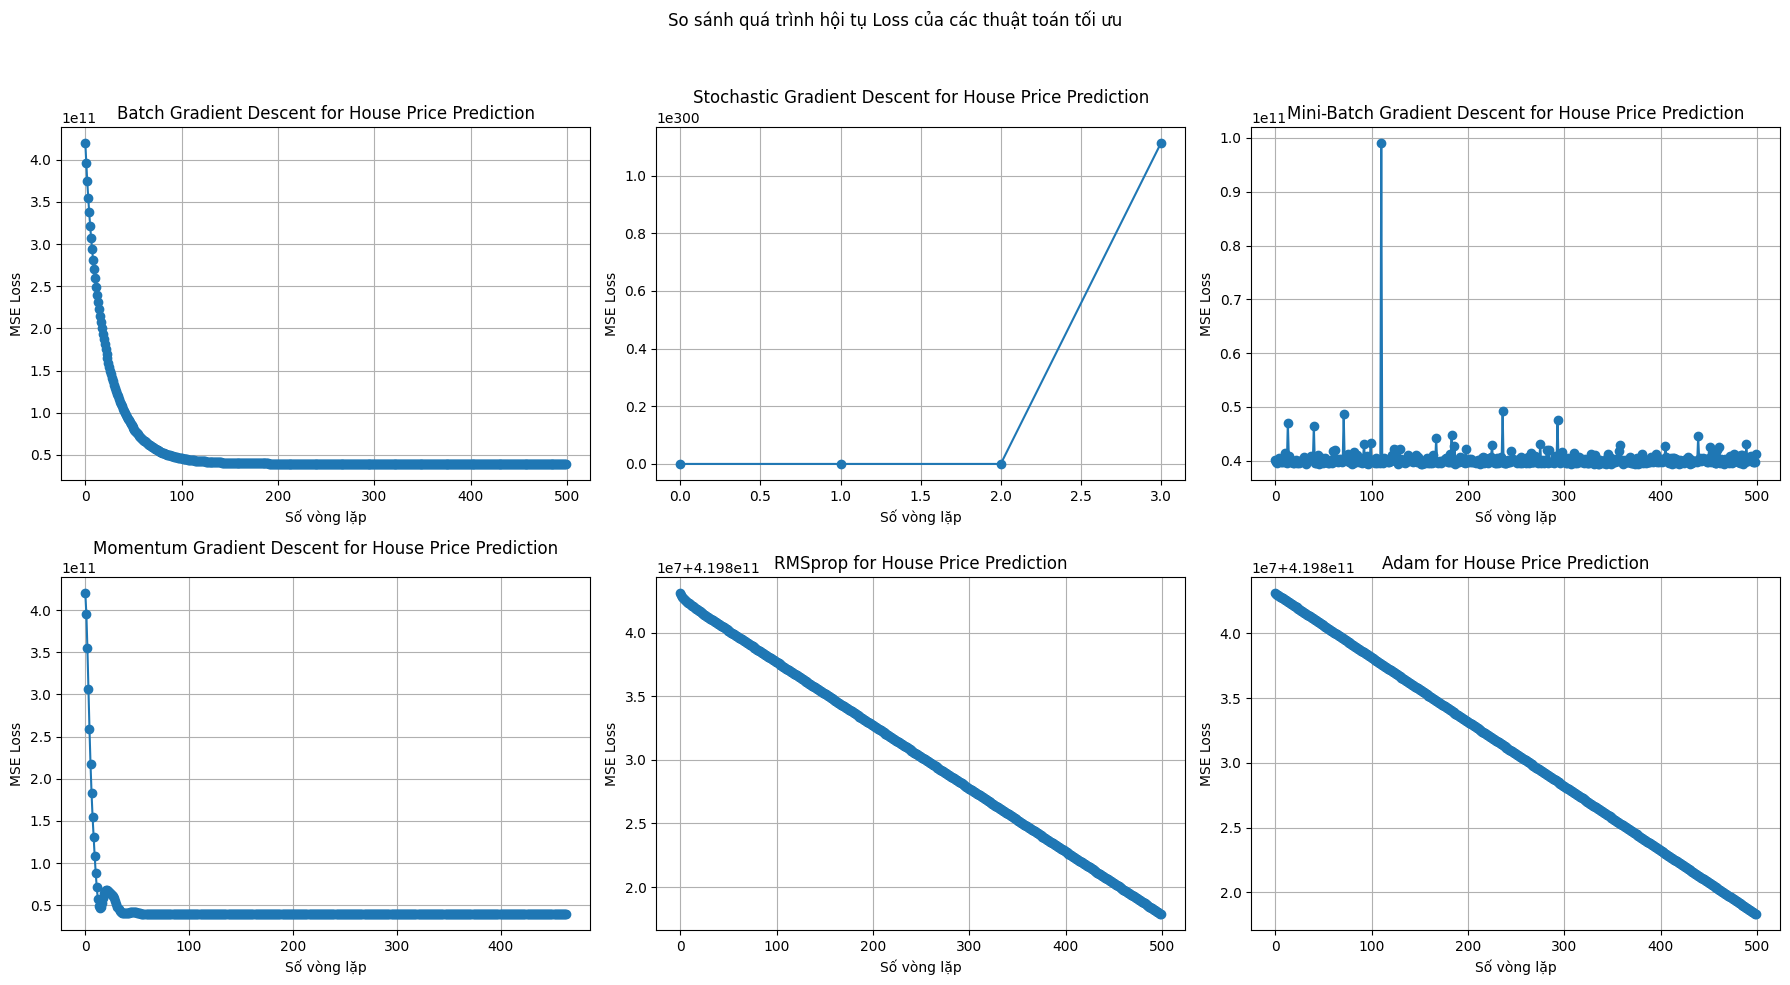

In [202]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, model in enumerate(models):
    iterations = np.arange(len(model.losses))
    axes[idx].plot(iterations, model.losses, marker='o', linestyle='-')
    axes[idx].set_xlabel("Số vòng lặp")
    axes[idx].set_ylabel("MSE Loss")
    axes[idx].set_title(model.name)
    axes[idx].grid(True)
fig.suptitle("So sánh quá trình hội tụ Loss của các thuật toán tối ưu")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()